### What Are Embeddings?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

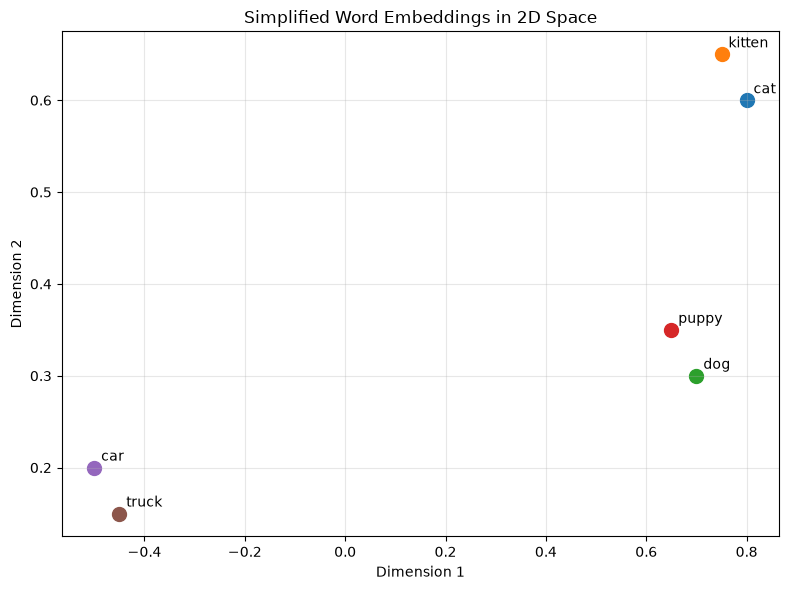

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s = 100)
    ax.annotate(word, (coords[0], coords[1]), xytext = (5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [6]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product = np.dot(vec1,vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)

In [7]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


## Creating Your First Embeddings

In [8]:
### Huggingface Model
from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API Key needed!)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

c:\Users\CHITTA\Desktop\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\CHITTA\Desktop\RAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CHITTA\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [9]:
## create your first embeddings
text="Hello, I am learning about embeddings!"

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)

Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.01816328428685665, -0.09955168515443802, 0.013816040940582752, -0.008125966414809227, 0.014152288436889648, 0.0640648603439331, -0.006253383122384548, -0.003017893061041832, 0.025287237018346786, -0.020198646932840347, 0.024329712614417076, 0.07435061782598495, 0.05117721110582352, 0.02203850820660591, -0.05830618366599083, 0.015268215909600258, 0.02358437515795231, 0.0945538729429245, -0.06508845090866089, 0.013296647928655148, -0.020497530698776245, -0.056908562779426575, 0.030303336679935455, -0.08365610241889954, 0.02659626118838787, -0.015231470577418804, -0.04361540824174881, 0.053984031081199646, 0.09025715291500092, -0.08893881738185883, 0.039644625037908554, -0.008835059590637684, -0.030343759804964066, 0.07425561547279358, -0.05409921333193779, 0.11107996851205826, 0.0368998646736145, -0.008959835395216942, -0.06140241026878357, -0.0031434057746082544, 0.02195819839835167, 0.04220818355679512, -0.02893787

In [10]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018348455429, -0.01187008898705244, -0.02811703085899353, 0.05123864859342575, -0.055974479764699936, 0.03019154630601406, 0.030161265283823013, 0.02469840832054615, -0.01837059296667576, 0.05876680463552475, -0.024953173473477364, 0.0601542629301548, 0.039831776171922684, 0.033230509608983994, -0.06131136044859886, -0.04937314614653587, -0.05486352741718292, -0.040076058357954025, 0.056429117918014526, 0.03915657475590706, -0.03473714366555214, -0.013247663155198097, 0.031966231763362885, -0.06349924206733704, -0.06017862260341644, 0.07823451608419418, -0.028303898870944977, -0.047442857176065445, 0.040359288454055786, -0.006630914285778999, -0.0667409673333168, -0.004191394429653883, -0.025311686098575592, 0.05334167927503586, 0.01742812804877758, -0.09792362153530121, 0.006061307154595852, -0.06524164229631424, 0.045572590082883835, 0.02364179864525795, 0.0765848234295845, -0.01026437059044838, -0.004076848272234201, -0.062322795391082764, 0.03370528295636177, 0.0186610929667

## 📊 Popular Open Source Embedding Models:

### Model: sentence-transformers/all-MiniLM-L6-v2
- 📏 Embedding size: 384 dimensions
- 📝 Description: Fast and efficient, good quality
- 🎯 Use case: General purpose, real-time applications

### Model: sentence-transformers/all-mpnet-base-v2
- 📏 Embedding size: 768 dimensions
- 📝 Description: Best quality, slower than MiniLM
- 🎯 Use case: When quality matters more than speed

### Model: sentence-transformers/all-MiniLM-L12-v2
- 📏 Embedding size: 384 dimensions
- 📝 Description: Slightly better than L6, bit slower
- 🎯 Use case: Good balance of speed and quality

### Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
- 📏 Embedding size: 384 dimensions
- 📝 Description: Optimized for question-answering
- 🎯 Use case: Q&A systems, semantic search

### Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
- 📏 Embedding size: 384 dimensions
- 📝 Description: Supports 50+ languages
- 🎯 Use case: Multilingual applications